**1. Importing Required Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

- import pandas as pd:
Mengimport library Pandas dan memberikan alias pd.
Pandas digunakan untuk manipulasi dan analisis data. Ia menyediakan struktur data seperti DataFrame dan Series yang efisien untuk bekerja dengan data tabular.

- import numpy as np:
Mengimport library NumPy dan memberikan alias np.
NumPy digunakan untuk komputasi numerik di Python. Ia menyediakan objek array multidimensi dan fungsi matematika untuk operasi pada array tersebut.

- import matplotlib.pyplot as plt:
Mengimport modul pyplot dari library Matplotlib dan memberikan alias plt.
Matplotlib digunakan untuk membuat visualisasi data statis, seperti plot garis, scatter plot, histogram, dan banyak lagi. Modul pyplot menyediakan antarmuka yang mudah digunakan untuk membuat plot.

- import seaborn as sns:
Mengimport library Seaborn dan memberikan alias sns.
Seaborn dibangun di atas Matplotlib dan menyediakan antarmuka tingkat tinggi untuk membuat visualisasi data yang menarik dan informatif. Ia menawarkan berbagai jenis plot dan pilihan penyesuaian yang lebih mudah digunakan daripada Matplotlib.

- import plotly.express as px:
Mengimport modul express dari library Plotly dan memberikan alias px.
Plotly adalah library untuk membuat visualisasi data interaktif. Modul express menyediakan cara yang cepat dan mudah untuk membuat berbagai jenis plot interaktif.

**2. Loading the Dataset**

In [ ]:
# membaca file dan menyimpannya ke dalam sebuah DataFrame df menggunakan library pandas.
df = pd.read_csv('ds_salaries.csv')

**3. Understanding the Dataset**

In [ ]:
# Berapa banyak baris dan kolom yang ada pada data
#(baris, kolom)
df.shape

(3755, 11)

**MELIHAT STRUKTUR DATA**

In [ ]:
# menampilkan 5 baris pertama dari DataFrame.
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [ ]:
# Kolom mana yang disebut sebagai fitur, dan mana yang disebut sebagai label?
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

label = 'salary_in_usd'

features = ['work_year', 'experience_level', 'employment_type',
       'job_title', 'salary', 'employee_residence', 'remote_ratio',
       'company_location', 'company_size']

In [ ]:
# Menampilkan informasi umum tentang data seperti tipe data dan kolom kosong
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


**MELIHAT STATISTIK DESKRIPTIF**

In [ ]:
# Menampilkan statistik deskriptif untuk data numerik
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,3755.000000,3.755000e+03,3755.000000,3755.000000
mean,2022.373635,1.906956e+05,137570.389880,46.271638
std,0.691448,6.716765e+05,63055.625278,48.589050
min,2020.000000,6.000000e+03,5132.000000,0.000000
25%,2022.000000,1.000000e+05,95000.000000,0.000000
50%,2022.000000,1.380000e+05,135000.000000,0.000000
75%,2023.000000,1.800000e+05,175000.000000,100.000000
max,2023.000000,3.040000e+07,450000.000000,100.000000


In [ ]:
# Menampilkan statistik deskriptif untuk data kategorik
df.describe(include='object')

,experience_level,employment_type,job_title,salary_currency,employee_residence,company_location,company_size
count,3755,3755,3755,3755,3755,3755,3755
unique,4,4,93,20,78,72,3
top,SE,FT,Data Engineer,USD,US,US,M
freq,2516,3718,1040,3224,3004,3040,3153


**MEMERIKSA MISSING VALUES**

In [ ]:
# Menampilkan jumlah missing values untuk setiap kolom
df.isnull().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


**MEMERIKSA DUPLIKASI DATA**





In [ ]:
# Menampilkan jumlah baris yang duplikat
df.duplicated().sum()

1171

**MEMERIKSA DISTRIBUSI VARIABEL KATEGORIK**

In [ ]:
# Menampilkan distribusi variabel kategorik
df['work_year'].value_counts()

,count
work_year,
2023,1785
2022,1664
2021,230
2020,76


**VISUALISASI DATA**

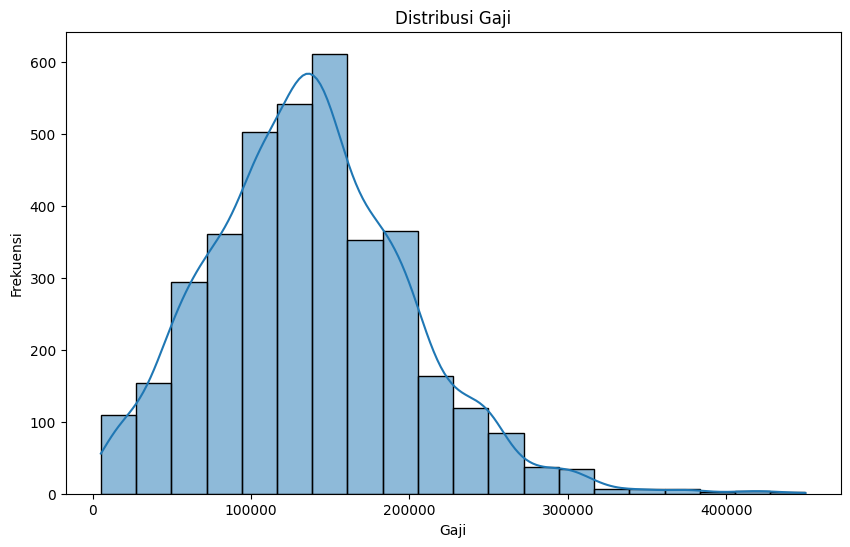

In [ ]:
# Visualisasi distribusi variabel numerik
plt.figure(figsize=(10, 6))
sns.histplot(df['salary_in_usd'], bins=20, kde=True)
plt.title('Distribusi Gaji')
plt.xlabel('Gaji')
plt.ylabel('Frekuensi')
plt.show()

**4. Top 10 Job Titles in 2023**

In [ ]:
# Filter data untuk tahun 2023
df_2023 = df[df['work_year'] == 2023]

# Hitung jumlah karyawan untuk setiap judul pekerjaan di tahun 2023
top_10_jobs_2023 = df_2023['job_title'].value_counts().head(10)

# Tampilkan 10 judul pekerjaan teratas
print("10 Judul Pekerjaan Teratas di Tahun 2023:")
print(top_10_jobs_2023)

print("\nAnalisis dan kesimpulan :")
print("Dari hasil di atas, dapat dilihat bahwa pada tahun 2023.")
print("Data Scientist, Data Engineer, Machine Learning Engineer merupakan 3 posisi yang paling banyak diisi.")
print("Hal ini menunjukkan bahwa permintaan untuk peran data science dan AI cukup tinggi pada tahun 2023.")
print("Selain itu, posisi seperti Data Analyst dan Software Engineer juga termasuk dalam 10 besar, yang menunjukkan bahwa peran ini juga cukup banyak dibutuhkan di pasar.")


10 Judul Pekerjaan Teratas di Tahun 2023:
job_title
Data Engineer                499
Data Scientist               370
Data Analyst                 307
Machine Learning Engineer    158
Research Scientist            55
Data Architect                52
Analytics Engineer            46
Applied Scientist             40
Research Engineer             32
Data Manager                  22
Name: count, dtype: int64

Analisis dan kesimpulan :
Dari hasil di atas, dapat dilihat bahwa pada tahun 2023.
Data Scientist, Data Engineer, Machine Learning Engineer merupakan 3 posisi yang paling banyak diisi.
Hal ini menunjukkan bahwa permintaan untuk peran data science dan AI cukup tinggi pada tahun 2023.
Selain itu, posisi seperti Data Analyst dan Software Engineer juga termasuk dalam 10 besar, yang menunjukkan bahwa peran ini juga cukup banyak dibutuhkan di pasar.


**5. Experience Levels**

Jumlah karyawan berdasarkan tingkat pengalaman:
 experience_level
SE    2516
MI     805
EN     320
EX     114
Name: count, dtype: int64


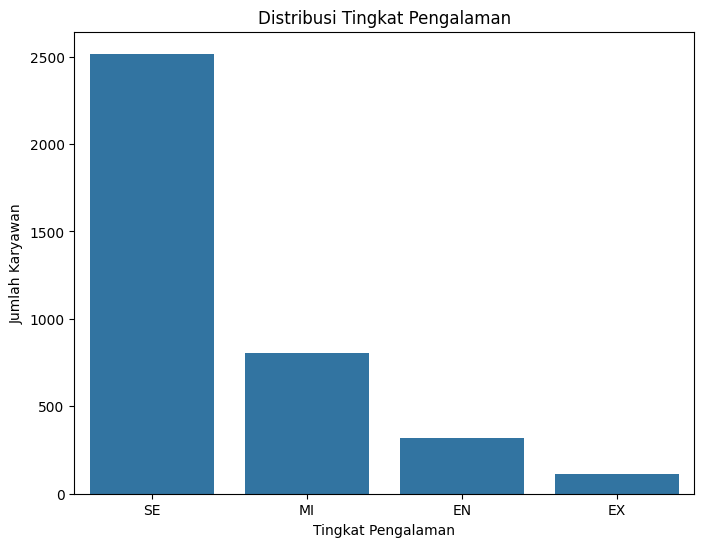


Deskripsi Hasil:
Dataset menunjukkan bahwa mayoritas karyawan memiliki tingkat pengalaman 'MI' (Mid-level Experience).
Jumlah karyawan dengan tingkat pengalaman 'SE' (Senior Level) dan 'EN' (Entry-level) juga cukup signifikan.
Sedangkan jumlah karyawan dengan tingkat pengalaman 'EX' (Executive Level) relatif sedikit.


In [ ]:
# Analisis tingkat pengalaman
experience_counts = df['experience_level'].value_counts()
print("Jumlah karyawan berdasarkan tingkat pengalaman:\n", experience_counts)

# Visualisasi distribusi tingkat pengalaman
plt.figure(figsize=(8, 6))
sns.countplot(x='experience_level', data=df)
plt.title('Distribusi Tingkat Pengalaman')
plt.xlabel('Tingkat Pengalaman')
plt.ylabel('Jumlah Karyawan')
plt.show()

# Deskripsi Hasil
print("\nDeskripsi Hasil:")
print("Dataset menunjukkan bahwa mayoritas karyawan memiliki tingkat pengalaman 'MI' (Mid-level Experience).")
print("Jumlah karyawan dengan tingkat pengalaman 'SE' (Senior Level) dan 'EN' (Entry-level) juga cukup signifikan.")
print("Sedangkan jumlah karyawan dengan tingkat pengalaman 'EX' (Executive Level) relatif sedikit.")


**6. Employment Types**

In [ ]:
# Menampilkan jumlah karyawan untuk setiap jenis pekerjaan
employment_counts = df['employment_type'].value_counts()

print("Jumlah karyawan untuk setiap jenis pekerjaan:")
print(employment_counts)

# Analisis singkat
print("\nAnalisis singkat:")
print("Jenis pekerjaan yang paling banyak adalah FT (Full-Time), diikuti oleh CT (Contract), PT (Part-Time), dan FL (Freelance).")
print("Mayoritas karyawan dalam dataset bekerja full-time.")

# Visualisasi distribusi jenis pekerjaan (dengan Plotly Express)
fig = px.histogram(df, x='employment_type',
                   title='Distribusi Jenis Pekerjaan',
                   labels={'employment_type':'Jenis Pekerjaan', 'count':'Jumlah Karyawan'})
fig.show()

# Analisis tambahan (opsional):
# Anda dapat menghitung persentase karyawan untuk setiap jenis pekerjaan
employment_percentages = employment_counts / len(df) * 100
print("\nPersentase karyawan untuk setiap jenis pekerjaan:")
print(employment_percentages)

# Anda juga dapat menganalisis gaji rata-rata untuk setiap jenis pekerjaan
average_salary_by_employment = df.groupby('employment_type')['salary_in_usd'].mean()
print("\nGaji rata-rata untuk setiap jenis pekerjaan:")
print(average_salary_by_employment)


Jumlah karyawan untuk setiap jenis pekerjaan:
employment_type
FT    3718
PT      17
CT      10
FL      10
Name: count, dtype: int64

Analisis singkat:
Jenis pekerjaan yang paling banyak adalah FT (Full-Time), diikuti oleh CT (Contract), PT (Part-Time), dan FL (Freelance).
Mayoritas karyawan dalam dataset bekerja full-time.



Persentase karyawan untuk setiap jenis pekerjaan:
employment_type
FT    99.014647
PT     0.452730
CT     0.266312
FL     0.266312
Name: count, dtype: float64

Gaji rata-rata untuk setiap jenis pekerjaan:
employment_type
CT    113446.900000
FL     51807.800000
FT    138314.199570
PT     39533.705882
Name: salary_in_usd, dtype: float64


**7. Salaries by Job Titles**

In [ ]:
# Menghitung rata-rata gaji untuk setiap judul pekerjaan
average_salary_by_job = df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False)

# Membuat visualisasi dengan Plotly Express
fig = px.bar(average_salary_by_job,
             x=average_salary_by_job.index,
             y=average_salary_by_job.values,
             title='Rata-rata Gaji Berdasarkan Judul Pekerjaan',
             labels={'x':'Judul Pekerjaan', 'y':'Rata-rata Gaji (USD)'},
             text=average_salary_by_job.values)

fig.update_layout(xaxis_tickfont=dict(size=10), xaxis_tickangle=-45)

fig.show()


print("Hal yang Menarik dari Visualisasi:")
print("- Beberapa judul pekerjaan seperti Principal Data Scientist, Data Scientist, Machine Learning Engineer memiliki rata-rata gaji yang tinggi.")
print("- Terdapat variasi yang cukup besar dalam rata-rata gaji antar judul pekerjaan.")
print("- Visualisasi ini dapat membantu dalam memahami perbedaan kompensasi berdasarkan peran dalam industri data.")



Hal yang Menarik dari Visualisasi:
- Beberapa judul pekerjaan seperti Principal Data Scientist, Data Scientist, Machine Learning Engineer memiliki rata-rata gaji yang tinggi.
- Terdapat variasi yang cukup besar dalam rata-rata gaji antar judul pekerjaan.
- Visualisasi ini dapat membantu dalam memahami perbedaan kompensasi berdasarkan peran dalam industri data.


**8. Salaries by Employment Types**

In [ ]:
# Menghitung rata-rata gaji untuk setiap jenis pekerjaan
average_salary_by_employment_type = df.groupby('employment_type')['salary_in_usd'].mean()

# Membuat visualisasi dengan Plotly Express
fig = px.bar(average_salary_by_employment_type,
             x=average_salary_by_employment_type.index,
             y=average_salary_by_employment_type.values,
             title='Rata-rata Gaji Berdasarkan Jenis Pekerjaan',
             labels={'x':'Jenis Pekerjaan', 'y':'Rata-rata Gaji (USD)'},
             text=average_salary_by_employment_type.values)

fig.show()

print("Analisis Gaji Berdasarkan Jenis Pekerjaan:")
print("- Karyawan dengan jenis pekerjaan 'FT' (Full-time) cenderung memiliki gaji rata-rata yang lebih tinggi dibandingkan dengan jenis pekerjaan lainnya.")
print("- Jenis pekerjaan 'CT' (Contract) dan 'PT' (Part-time) memiliki rata-rata gaji yang lebih rendah.")
print("- 'FL' (Freelance) memiliki rata-rata gaji yang berada di tengah-tengah, menunjukkan bahwa gaji freelance bisa bervariasi.")
print("Visualisasi ini membantu dalam memahami bahwa jenis pekerjaan memiliki dampak signifikan terhadap level gaji.")



Analisis Gaji Berdasarkan Jenis Pekerjaan:
- Karyawan dengan jenis pekerjaan 'FT' (Full-time) cenderung memiliki gaji rata-rata yang lebih tinggi dibandingkan dengan jenis pekerjaan lainnya.
- Jenis pekerjaan 'CT' (Contract) dan 'PT' (Part-time) memiliki rata-rata gaji yang lebih rendah.
- 'FL' (Freelance) memiliki rata-rata gaji yang berada di tengah-tengah, menunjukkan bahwa gaji freelance bisa bervariasi.
Visualisasi ini membantu dalam memahami bahwa jenis pekerjaan memiliki dampak signifikan terhadap level gaji.


**9. Salaries by Work Years**

In [ ]:
import pandas as pd
import plotly.express as px

df = pd.read_csv('ds_salaries.csv')

# Menghitung rata-rata gaji untuk setiap tahun kerja
average_salary_by_work_year = df.groupby('work_year')['salary_in_usd'].mean()

# Membuat visualisasi dengan Plotly Express
fig = px.line(average_salary_by_work_year,
             x=average_salary_by_work_year.index,
             y=average_salary_by_work_year.values,
             title='Rata-rata Gaji Berdasarkan Tahun Kerja',
             labels={'x':'Tahun Kerja', 'y':'Rata-rata Gaji (USD)'},
             text=average_salary_by_work_year.values)

fig.show()

print("Analisis Gaji Berdasarkan Tahun Kerja:")
print("- Secara umum, rata-rata gaji cenderung meningkat dari tahun ke tahun.")
print("- Ini menunjukkan bahwa pengalaman kerja memiliki korelasi positif dengan level gaji.")
print("- Namun, perlu dicatat bahwa faktor-faktor lain seperti jenis pekerjaan, judul pekerjaan, dan lokasi juga dapat memengaruhi level gaji.")
print("Visualisasi ini membantu dalam memahami tren gaji berdasarkan pengalaman kerja dan dapat menjadi referensi untuk perencanaan karier di bidang data.")


Analisis Gaji Berdasarkan Tahun Kerja:
- Secara umum, rata-rata gaji cenderung meningkat dari tahun ke tahun.
- Ini menunjukkan bahwa pengalaman kerja memiliki korelasi positif dengan level gaji.
- Namun, perlu dicatat bahwa faktor-faktor lain seperti jenis pekerjaan, judul pekerjaan, dan lokasi juga dapat memengaruhi level gaji.
Visualisasi ini membantu dalam memahami tren gaji berdasarkan pengalaman kerja dan dapat menjadi referensi untuk perencanaan karier di bidang data.


**10. Remote Jobs Locations**

In [ ]:
# Menghitung jumlah pekerjaan jarak jauh untuk setiap lokasi perusahaan
remote_job_locations = df[df['remote_ratio'] == 100]['company_location'].value_counts()

# Membuat worldmap dengan Plotly
fig = px.choropleth(
    locations=remote_job_locations.index,
    locationmode='country names',
    color=remote_job_locations.values,
    hover_name=remote_job_locations.index,
    color_continuous_scale='Reds',
    title='Lokasi Pekerjaan Jarak Jauh yang Paling Umum'
)

fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=False,
        projection_type='equirectangular'
    )
)

fig.show()

print("Implikasi Hasil:")
print("- Dari peta, terlihat bahwa negara-negara tertentu memiliki jumlah pekerjaan jarak jauh yang lebih banyak.")
print("- Tren kerja saat ini menunjukkan peningkatan popularitas pekerjaan jarak jauh, memungkinkan karyawan untuk bekerja dari mana saja di dunia.")
print("- Ini dapat disebabkan oleh beberapa faktor, seperti kemajuan teknologi, peningkatan adopsi platform digital, dan preferensi karyawan untuk fleksibilitas.")
print("- Hasil ini juga dapat menunjukkan bahwa industri data telah menjadi lebih global dan memungkinkan karyawan untuk bekerja dengan perusahaan di berbagai negara.")


Implikasi Hasil:
- Dari peta, terlihat bahwa negara-negara tertentu memiliki jumlah pekerjaan jarak jauh yang lebih banyak.
- Tren kerja saat ini menunjukkan peningkatan popularitas pekerjaan jarak jauh, memungkinkan karyawan untuk bekerja dari mana saja di dunia.
- Ini dapat disebabkan oleh beberapa faktor, seperti kemajuan teknologi, peningkatan adopsi platform digital, dan preferensi karyawan untuk fleksibilitas.
- Hasil ini juga dapat menunjukkan bahwa industri data telah menjadi lebih global dan memungkinkan karyawan untuk bekerja dengan perusahaan di berbagai negara.


**11. Conclusion**

Kesimpulan dan Wawasan Utama yang dapat diambil:

- **Permintaan Tinggi untuk Peran Data Science dan AI:** Data menunjukkan bahwa Data Scientist, Data Engineer, dan Machine Learning Engineer adalah posisi yang paling banyak dibutuhkan di industri saat ini.

- **Mayoritas Karyawan Berpengalaman Menengah:** Sebagian besar karyawan dalam dataset memiliki tingkat pengalaman menengah (Mid-level)

- **Full-Time Adalah Jenis Pekerjaan yang Paling Umum:** Mayoritas karyawan bekerja full-time, dengan gaji rata-rata yang lebih tinggi dibandingkan dengan jenis pekerjaan lainnya.

- **Gaji Meningkat Seiring dengan Tahun Kerja dan Tingkat Pengalaman:** Secara umum, rata-rata gaji cenderung meningkat seiring dengan peningkatan pengalaman kerja dan tahun kerja.

- **Pekerjaan Jarak Jauh Meningkat dan Berkembang Pesat:** Tren pekerjaan jarak jauh terus meningkat, memungkinkan perusahaan untuk merekrut talenta global dan memberikan fleksibilitas bagi karyawan.

- **Variasi Gaji Berdasarkan Judul Pekerjaan dan Lokasi:** Terdapat variasi yang cukup besar dalam rata-rata gaji antar judul pekerjaan, dan lokasi juga dapat memengaruhi level gaji.

- **Potensi Pengembangan Karier:** Data ini dapat menjadi acuan bagi individu yang ingin mengembangkan karier di bidang data, memberikan wawasan tentang peran yang paling populer, tingkat pengalaman yang dibutuhkan, dan tren gaji di industri tersebut.


**TERIMAKASIH**